In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.graph_objects import Figure
from plotly.subplots import make_subplots

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Monetary_Economics.csv')

In [3]:
df.rename(columns={
    "COUNTRY": "Country",
    "MONTH": "Date",
    "INF": "CPI Inflation",
    "EXR": "Exchange Rate",
    "INR": " Lending Interest Rate",
    "WOP": "World Oil Price",
    "GEA": "Global Economic Activity"
}, inplace=True)

In [4]:
df = df.drop(['INF2','GEA2 '], axis=1)
df.head()

,Country,Date,CPI Inflation,Exchange Rate,Lending Interest Rate,World Oil Price,Global Economic Activity
0,ALGERIA,01/01/2000,2.242235,70.7292,10.0,27.224286,-10.028534
1,ALGERIA,01/02/2000,2.426637,72.4357,10.0,29.362381,-8.681862
2,ALGERIA,01/03/2000,1.660758,73.4741,10.0,29.892174,5.995629
3,ALGERIA,01/04/2000,0.924354,76.0025,10.0,25.799000,9.081429
4,ALGERIA,01/05/2000,-0.485800,75.2502,10.0,28.833478,5.096124


In [5]:
# The Dataset is a panel Data
# I created a for loop to divide the data based on their country
countries = df['Country'].unique()

country_data = {}

for country in countries:
  country_data[country] = (
      df[df['Country'] == country]
      .reset_index(drop=True)
      )

In [6]:
df_kenya = country_data['KENYA']
df_kenya.head()

,Country,Date,CPI Inflation,Exchange Rate,Lending Interest Rate,World Oil Price,Global Economic Activity
0,KENYA,01/01/2000,9.716981,72.8139,25.14,27.224286,-10.028534
1,KENYA,01/02/2000,7.600733,73.3972,25.39,29.362381,-8.681862
2,KENYA,01/03/2000,5.951307,74.8739,23.79,29.892174,5.995629
3,KENYA,01/04/2000,7.258065,74.8556,23.44,25.799000,9.081429
4,KENYA,01/05/2000,8.568905,76.7033,23.40,28.833478,5.096124


In [8]:
fig = px.line(df_kenya, x='Date', y='Exchange Rate')
fig.update_layout(
    title='KES/USD Forex Chart Trend',
    xaxis_title='Monthly Exchange Rate (2000 - 2023)',
    yaxis_title='Exchange Rate (KES/USD)'
)
fig.show()

In [23]:
combined_fig = px.line(
    df_kenya,
    x='Date',
    y=[' Lending Interest Rate', 'CPI Inflation'],
    title='KENYA Economic Trends: Lending Interest Rate vs CPI Inflation (2000 - 2023)',
    color_discrete_map={' Lending Interest Rate': 'blue', 'CPI Inflation': 'red'}
)


combined_fig.update_layout(
    xaxis_title='Date (Monthly)',
    yaxis_title='Percentage (%)',
    legend_title='Metrics'
)

combined_fig.show()


In [36]:
ind_color_map = {"World Oil Price": "rgb(124, 250, 120)", "Global Economic Activity": "rgb(112,128,144)"}
fig_gea_wop = px.line(
    data_frame=df_kenya,
    x='Date',
    y=['World Oil Price', 'Global Economic Activity'],
    title='International Economic Trends: World Oil Price vs Global Economic Activity (2000 - 2023)',
    color_discrete_map=ind_color_map
)

fig_gea_wop.add_annotation(
    x='01/11/2008',
    y=-66,
    text="2008 Global Financial Crisis",
    showarrow=True,
)

fig_gea_wop.update_layout(
    xaxis_title='Date (Monthly)',
    yaxis_title='Percentage (%)',

)


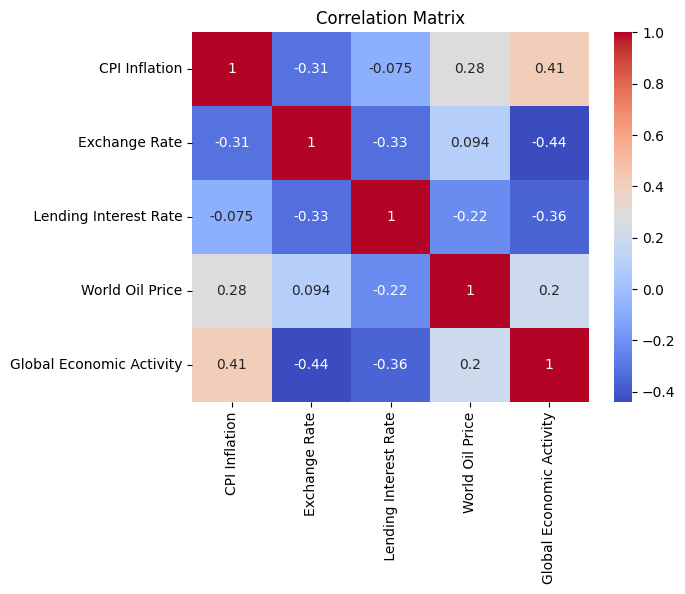

In [40]:
# Correlation
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df_kenya.drop(['Country','Date'], axis=1).reset_index(drop=True).corr()
corr_matrix

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [41]:
fig_inf_wop = px.line(
    data_frame=df_kenya,
    x='Date',
    y=['World Oil Price', 'CPI Inflation'],
    title='KENYA Economic Trends: World Oil Price vs CPI Inflation (2000 - 2023)',
)

fig_inf_wop.update_layout(
    xaxis_title='Date (Monthly)',
    yaxis_title='Percentage (%)',
    legend_title='Metrics'
)

fig_inf_wop.show()

In [50]:
df_sa = country_data['S. AFRICA']
df_sa.head()

,Country,Date,CPI Inflation,Exchange Rate,Lending Interest Rate,World Oil Price,Global Economic Activity
0,S. AFRICA,01/01/2000,2.648312,6.3075,14.5,27.224286,-10.028534
1,S. AFRICA,01/02/2000,2.330514,6.3445,14.5,29.362381,-8.681862
2,S. AFRICA,01/03/2000,3.389839,6.5615,14.5,29.892174,5.995629
3,S. AFRICA,01/04/2000,4.545466,6.8185,14.5,25.799000,9.081429
4,S. AFRICA,01/05/2000,5.079378,6.9585,14.5,28.833478,5.096124


In [51]:
fig_sa = px.line(df_sa, x='Date', y='Exchange Rate')
fig_sa.update_layout(
    title='ZAR/USD Forex Chart Trend',
    xaxis_title='Monthly Exchange Rate (2000 - 2023)',
    yaxis_title='Exchange Rate (ZAR/USD)'
)
fig_sa.show()

In [52]:
df_inf_inr = px.line(
    data_frame=df_sa,
    x='Date',
    y=[' Lending Interest Rate', 'CPI Inflation'],
    title='S. AFRICA Economic Trends: Lending Interest Rate vs CPI Inflation (2000 - 2023)')

df_inf_inr.update_layout(
    xaxis_title='Date (Monthly)',
    yaxis_title='Percentage (%)',
    legend_title='Metrics'
)

df_inf_inr.show()